# Pipeline PLN — Amazon Fine Food Reviews

**Disciplina:** Sistemas Cognitivos e Linguagem Natural

**Questão:** Como construir um pipeline completo de PLN para transformar avaliações brutas da Amazon em informações úteis sobre satisfação, temas e relações entre produtos/marcas/categorias?

**Corpus:** [Amazon Fine Food Reviews (Kaggle)](https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews) — se a amostra nao existir, o notebook baixa `Reviews.csv` via **kagglehub** e gera `amazon_reviews_sample.csv` (10k reviews, 8 grupos `Gourmet_Foods_G1`–`G8`). Credenciais: `~/.kaggle/kaggle.json` ou variaveis `KAGGLE_USERNAME` / `KAGGLE_KEY`.

In [59]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn nltk spacy gensim wordcloud networkx pyvis vaderSentiment python-Levenshtein pyLDAvis kagglehub

Note: you may need to restart the kernel to use updated packages.


In [31]:
import os
import re
import warnings
from collections import Counter

import Levenshtein
import matplotlib.pyplot as plt
import networkx as nx
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
from gensim.models import Word2Vec
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import sent_tokenize, word_tokenize
from pyvis.network import Network
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

for pkg in ("punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"):
    nltk.download(pkg, quiet=True)

SPACY_MODEL = "en_core_web_sm"


def ensure_spacy_model(name):
    if spacy.util.is_package(name):
        return
    import subprocess
    import sys
    subprocess.check_call(
        [sys.executable, "-m", "spacy", "download", name],
        stdout=subprocess.DEVNULL,
    )


ensure_spacy_model(SPACY_MODEL)
nlp = spacy.load(SPACY_MODEL, disable=["parser", "ner"])
nlp_full = spacy.load(SPACY_MODEL)

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "scripts" else os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "data", "sample", "amazon_reviews_sample.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

CUSTOM_STOPWORDS = {
    "amazon", "product", "review", "purchase", "item", "would", "also", "one",
    "get", "got", "use", "used", "really", "much", "even", "well", "could",
}
stop_en = set(stopwords.words("english")) | CUSTOM_STOPWORDS
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
vader = SentimentIntensityAnalyzer()

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")


In [62]:
import subprocess
import sys

REVIEWS_PATH = os.path.join(BASE_DIR, "data", "sample", "Reviews.csv")
SAMPLE_PATH = DATA_PATH


def ensure_project_data():
    os.makedirs(os.path.dirname(SAMPLE_PATH), exist_ok=True)
    if os.path.isfile(SAMPLE_PATH):
        print(f"Amostra pronta: {SAMPLE_PATH}")
        return

    if not os.path.isfile(REVIEWS_PATH):
        print("Baixando snap/amazon-fine-food-reviews via kagglehub...")
        import kagglehub

        cached = kagglehub.dataset_download(
            "snap/amazon-fine-food-reviews",
            path="Reviews.csv",
        )
        src = cached if os.path.isfile(cached) else os.path.join(cached, "Reviews.csv")
        for enc in ("utf-8", "latin-1", "cp1252"):
            try:
                reviews_df = pd.read_csv(src, low_memory=False, encoding=enc)
                break
            except UnicodeDecodeError:
                continue
        else:
            reviews_df = pd.read_csv(
                src, low_memory=False, encoding="latin-1", encoding_errors="replace"
            )
        reviews_df.to_csv(REVIEWS_PATH, index=False, encoding="utf-8")
        print(f"Reviews.csv salvo ({len(reviews_df):,} linhas, UTF-8)")

    print("Gerando amazon_reviews_sample.csv...")
    script = os.path.join(BASE_DIR, "scripts", "build_sample.py")
    subprocess.check_call([sys.executable, script], cwd=BASE_DIR)


ensure_project_data()

Baixando snap/amazon-fine-food-reviews via kagglehub...


100%|██████████| 115M/115M [00:04<00:00, 27.7MB/s] 


ValueError: Error reading file: 'utf-8' codec can't decode byte 0xf9 in position 10: invalid start byte

## Bloco 1 — Caracterização do corpus

In [32]:
df = pd.read_csv(DATA_PATH)
if "texto_completo" not in df.columns:
    df["texto_completo"] = (df["review_headline"].fillna("") + " " + df["review_body"].fillna("")).str.strip()
if "sentimento" not in df.columns:
    df["sentimento"] = np.where(df["star_rating"] >= 4, "positivo", np.where(df["star_rating"] <= 2, "negativo", None))
    df = df.dropna(subset=["sentimento"])
if "categoria_top" not in df.columns:
    df["categoria_top"] = df["product_category"]

df["n_palavras"] = df["texto_completo"].str.split().str.len()
df["n_chars"] = df["texto_completo"].str.len()

print(f"Documentos: {len(df):,}")
print(f"Média de palavras: {df['n_palavras'].mean():.1f}")
print(f"Categorias: {df['categoria_top'].nunique()}")
print(f"Mediana de palavras: {df['n_palavras'].median():.0f}")
print("Rotulo sentimento: derivado de star_rating (>=4 positivo, <=2 negativo); notas neutras excluidas.")
df.info()
df[["star_rating", "n_palavras", "n_chars"]].describe()


Documentos: 10,000
Média de palavras: 204.2
Categorias: 8
Mediana de palavras: 171
Rotulo sentimento: derivado de star_rating (>=4 positivo, <=2 negativo); notas neutras excluidas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   marketplace        10000 non-null  object 
 1   review_id          10000 non-null  int64  
 2   product_id         10000 non-null  object 
 3   product_title      10000 non-null  object 
 4   product_category   10000 non-null  object 
 5   categoria_top      10000 non-null  object 
 6   star_rating        10000 non-null  int64  
 7   sentimento         10000 non-null  object 
 8   verified_purchase  0 non-null      float64
 9   review_headline    10000 non-null  object 
 10  review_body        10000 non-null  object 
 11  texto_completo     10000 non-null  object 
 12  review_date        10000 non-null 

,star_rating,n_palavras,n_chars
count,10000.000000,10000.000000,10000.00000
mean,4.066100,204.244800,1096.80750
std,1.200781,108.085128,594.47431
min,1.000000,93.000000,503.00000
25%,4.000000,136.000000,723.00000
50%,4.000000,171.000000,916.00000
75%,5.000000,233.000000,1258.25000
max,5.000000,1416.000000,7729.00000


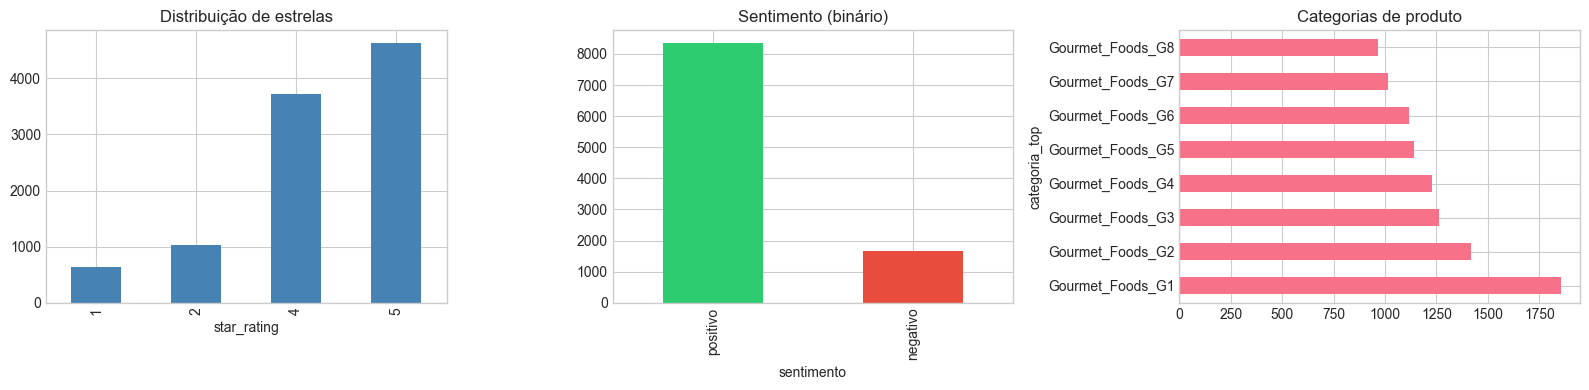

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df["star_rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Distribuição de estrelas")
axes[0].set_xlabel("star_rating")

df["sentimento"].value_counts().plot(kind="bar", ax=axes[1], color=["#2ecc71", "#e74c3c"])
axes[1].set_title("Sentimento (binário)")

df["categoria_top"].value_counts().plot(kind="barh", ax=axes[2])
axes[2].set_title("Categorias de produto")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_classes.png"), dpi=120, bbox_inches="tight")
plt.show()


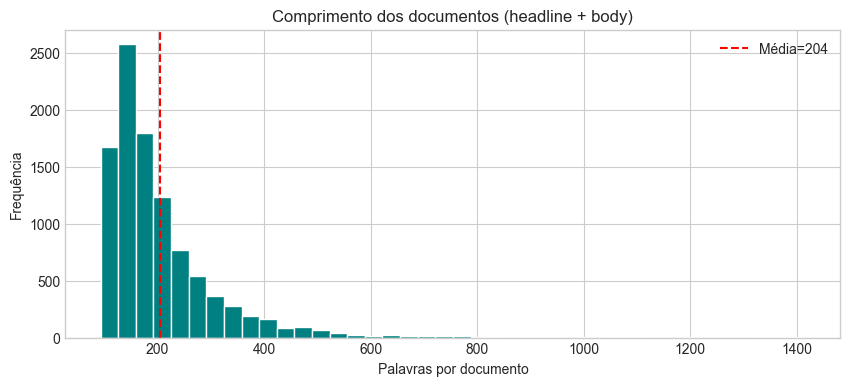

Reviews Amazon tendem a ser mais curtas que 200 palavras; usamos headline+body e filtro mínimo de 30 palavras.


In [34]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["n_palavras"], bins=40, color="teal", edgecolor="white")
ax.axvline(df["n_palavras"].mean(), color="red", linestyle="--", label=f"Média={df['n_palavras'].mean():.0f}")
ax.set_xlabel("Palavras por documento")
ax.set_ylabel("Frequência")
ax.set_title("Comprimento dos documentos (headline + body)")
ax.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "histograma_comprimento.png"), dpi=120, bbox_inches="tight")
plt.show()

print(
    f"Corpus Fine Food: media {df['n_palavras'].mean():.0f} palavras/doc "
    f"(amostra filtrada com reviews longas, ver scripts/build_sample.py)."
)


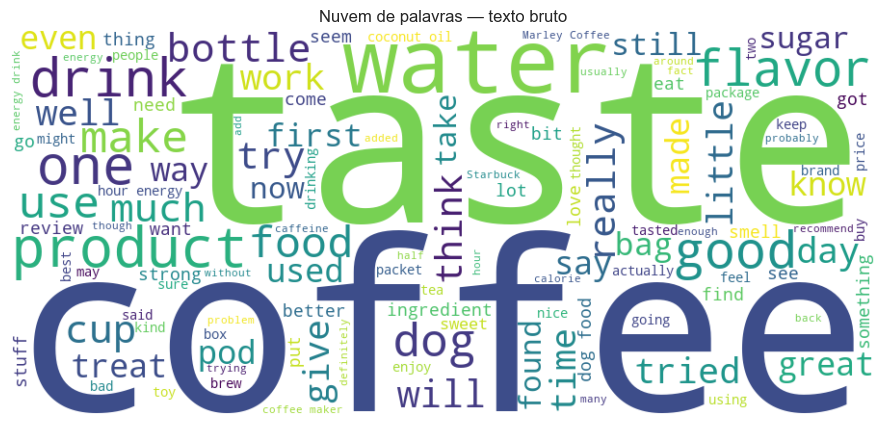

In [35]:
wc = WordCloud(width=900, height=400, background_color="white", max_words=120).generate(
    " ".join(df["texto_completo"].head(3000))
)
plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de palavras — texto bruto")
plt.savefig(os.path.join(OUTPUT_DIR, "wordcloud_bruto.png"), dpi=120, bbox_inches="tight")
plt.show()


## Bloco 2 — Pré-processamento (NLTK + spaCy)

In [36]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def tokenize_words(text):
    return word_tokenize(normalize_text(text))


def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_en and len(t) > 2]


def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]


def lemma_nltk_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]


def lemma_spacy_text(text):
    doc = nlp(normalize_text(text))
    return [t.lemma_ for t in doc if t.lemma_ not in stop_en and not t.is_space and len(t.lemma_) > 2]


def preprocess_pipeline(text, method="lemma_spacy"):
    tokens = tokenize_words(text)
    tokens = remove_stopwords(tokens)
    if method == "stem":
        return stem_tokens(tokens)
    if method == "lemma_nltk":
        return lemma_nltk_tokens(tokens)
    return lemma_spacy_text(text)


def tokens_to_str(tokens):
    return " ".join(tokens)


In [37]:
sample_text = df["texto_completo"].iloc[0]
print("Sentenças:", sent_tokenize(sample_text)[:2])
print("Tokens:", tokenize_words(sample_text)[:15])
print("Stem:", stem_tokens(remove_stopwords(tokenize_words(sample_text)))[:15])
print("Lemma spaCy:", lemma_spacy_text(sample_text)[:15])


Sentenças: ['Starbucks Natural Fusions Vanilla Coffee Tastes Great When Brewed With A Keurig One-Cup Coffee Maker My parents and I enjoyed drinking Starbucks Natural Fusions Vanilla Ground Coffee over the holidays.', 'Mom graciously made it with her antiquated percolator.']
Tokens: ['starbucks', 'natural', 'fusions', 'vanilla', 'coffee', 'tastes', 'great', 'when', 'brewed', 'with', 'a', 'keurig', 'one', 'cup', 'coffee']
Stem: ['starbuck', 'natur', 'fusion', 'vanilla', 'coffe', 'tast', 'great', 'brew', 'keurig', 'cup', 'coffe', 'maker', 'parent', 'enjoy', 'drink']
Lemma spaCy: ['starbuck', 'natural', 'fusion', 'vanilla', 'coffee', 'taste', 'great', 'brew', 'keurig', 'cup', 'coffee', 'maker', 'parent', 'enjoy', 'drink']


,estrategia,tamanho_vocabulario
0,bruto (5k docs),20111
1,stemming,10417
2,lemmatização spaCy,12202


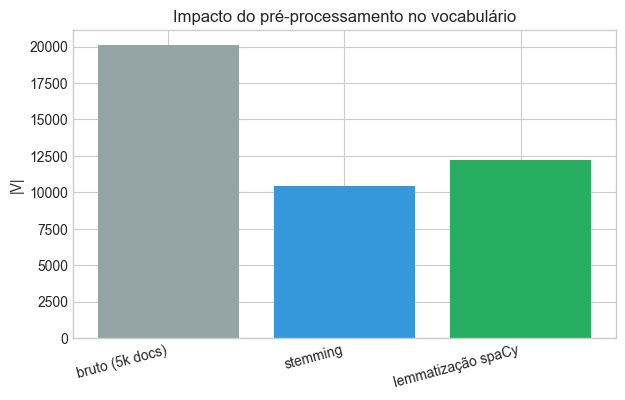

Decisão: lemmatização spaCy para modelos e busca — preserva interpretabilidade sem perder semântica como o stemming.


In [38]:
df["tokens_stem"] = df["texto_completo"].apply(lambda t: preprocess_pipeline(t, "stem"))

texts_norm = [normalize_text(t) for t in df["texto_completo"]]
tokens_lemma_list = []
for doc in nlp.pipe(texts_norm, batch_size=256):
    tokens_lemma_list.append([t.lemma_ for t in doc if t.lemma_ not in stop_en and not t.is_space and len(t.lemma_) > 2])
df["tokens_lemma"] = tokens_lemma_list
df["texto_processado"] = df["tokens_lemma"].apply(tokens_to_str)

vocab_bruto = len(set(word_tokenize(" ".join(df["texto_completo"].head(5000).str.lower()))))
vocab_stem = len(set(t for row in df["tokens_stem"].head(5000) for t in row))
vocab_lemma = len(set(t for row in df["tokens_lemma"].head(5000) for t in row))

comp = pd.DataFrame({
    "estrategia": ["bruto (5k docs)", "stemming", "lemmatização spaCy"],
    "tamanho_vocabulario": [vocab_bruto, vocab_stem, vocab_lemma],
})
display(comp)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(comp["estrategia"], comp["tamanho_vocabulario"], color=["#95a5a6", "#3498db", "#27ae60"])
ax.set_ylabel("|V|")
ax.set_title("Impacto do pré-processamento no vocabulário")
plt.xticks(rotation=15, ha="right")
plt.savefig(os.path.join(OUTPUT_DIR, "vocabulario_preprocessamento.png"), dpi=120, bbox_inches="tight")
plt.show()

print("Decisão: lemmatização spaCy para modelos e busca — preserva interpretabilidade sem perder semântica como o stemming.")


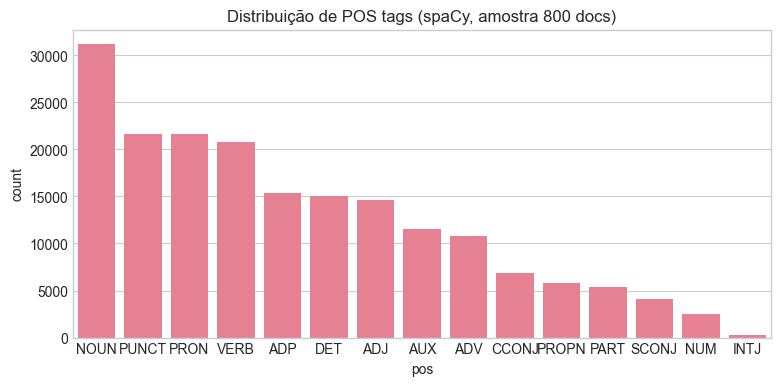

In [39]:
pos_counts = Counter()
for text in df["texto_completo"].sample(800, random_state=RANDOM_STATE):
    doc = nlp_full(str(text)[:5000])
    pos_counts.update([t.pos_ for t in doc])

pos_df = pd.DataFrame(pos_counts.items(), columns=["pos", "count"]).sort_values("count", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=pos_df, x="pos", y="count", ax=ax)
ax.set_title("Distribuição de POS tags (spaCy, amostra 800 docs)")
plt.savefig(os.path.join(OUTPUT_DIR, "pos_tags.png"), dpi=120, bbox_inches="tight")
plt.show()


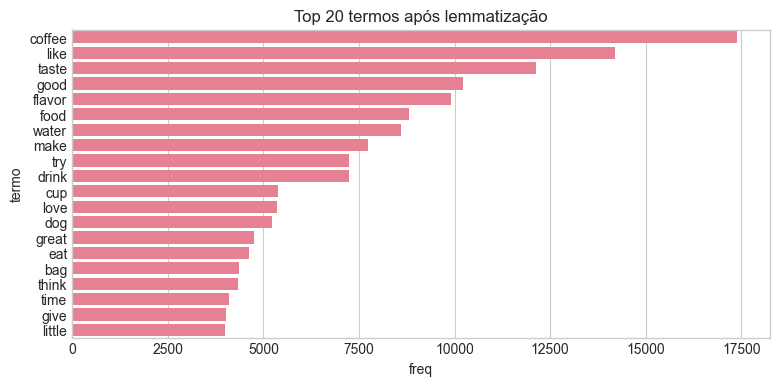

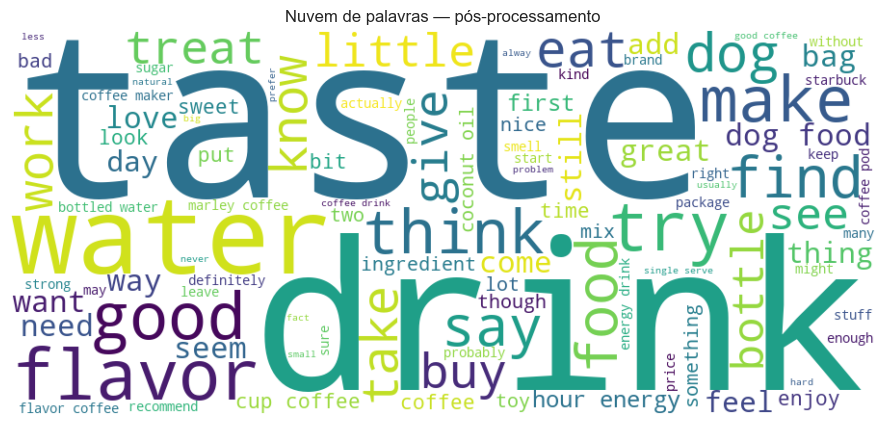

In [40]:
term_freq = Counter()
for tokens in df["tokens_lemma"]:
    term_freq.update(tokens)
top20 = pd.DataFrame(term_freq.most_common(20), columns=["termo", "freq"])

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=top20, y="termo", x="freq", ax=ax)
ax.set_title("Top 20 termos após lemmatização")
plt.savefig(os.path.join(OUTPUT_DIR, "termos_frequentes.png"), dpi=120, bbox_inches="tight")
plt.show()

wc2 = WordCloud(width=900, height=400, background_color="white", max_words=100).generate(
    " ".join(df["texto_processado"].head(3000))
)
plt.figure(figsize=(12, 5))
plt.imshow(wc2, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de palavras — pós-processamento")
plt.savefig(os.path.join(OUTPUT_DIR, "wordcloud_processado.png"), dpi=120, bbox_inches="tight")
plt.show()


## Bloco 3 — Representação vetorial e busca textual

BoW shape: (10000, 5000)
TF-IDF shape: (10000, 8000)
Word2Vec vocab: 9012


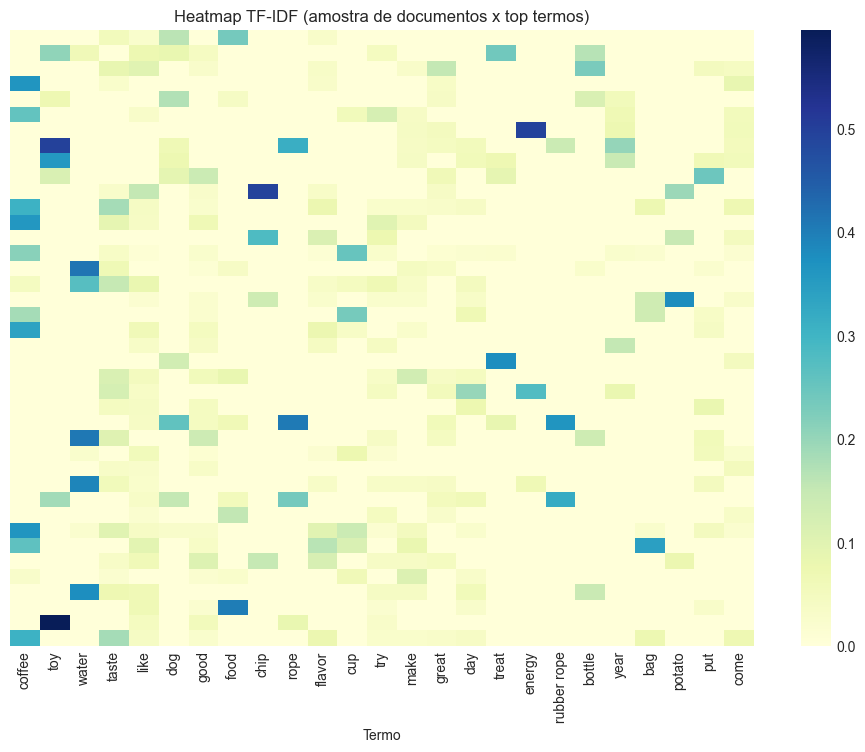

In [41]:
corpus = df["texto_processado"].tolist()

bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(corpus)

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3)
X_tfidf = tfidf.fit_transform(corpus)

sentences = [t.split() for t in corpus]
w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=3, workers=2, seed=RANDOM_STATE, epochs=10)

print("BoW shape:", X_bow.shape)
print("TF-IDF shape:", X_tfidf.shape)
print("Word2Vec vocab:", len(w2v.wv))
for termo in ["coffee", "flavor", "refund", "starbucks"]:
    if termo in w2v.wv:
        vizinhos = w2v.wv.most_similar(termo, topn=5)
        print(f"Vizinhos de '{termo}':", [w for w, _ in vizinhos])

sample_idx = np.random.default_rng(RANDOM_STATE).choice(
    X_tfidf.shape[0], size=min(40, X_tfidf.shape[0]), replace=False
)
feat_idx = np.array(X_tfidf[sample_idx].sum(axis=0)).flatten().argsort()[-25:][::-1]
feat_names = [tfidf.get_feature_names_out()[i] for i in feat_idx]
heat_tfidf = X_tfidf[sample_idx][:, feat_idx].toarray()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    heat_tfidf,
    xticklabels=feat_names,
    yticklabels=False,
    cmap="YlGnBu",
    ax=ax,
)
ax.set_title("Heatmap TF-IDF (amostra de documentos x top termos)")
ax.set_xlabel("Termo")
plt.savefig(os.path.join(OUTPUT_DIR, "heatmap_tfidf.png"), dpi=120, bbox_inches="tight")
plt.show()


In [42]:
from sklearn.metrics.pairwise import cosine_similarity


def doc_embedding(tokens):
    vecs = [w2v.wv[t] for t in tokens if t in w2v.wv]
    if not vecs:
        return np.zeros(w2v.vector_size)
    return np.mean(vecs, axis=0)


doc_vectors = np.vstack([doc_embedding(t) for t in df["tokens_lemma"]])


def buscar_similares(query, vectorizer, matrix, top_k=5):
    q = preprocess_pipeline(query, "lemma_spacy")
    q_str = tokens_to_str(q)
    q_vec = vectorizer.transform([q_str])
    scores = cosine_similarity(q_vec, matrix).flatten()
    idx = scores.argsort()[::-1][:top_k]
    return df.iloc[idx][["review_headline", "star_rating", "sentimento", "categoria_top"]].assign(score=scores[idx])


consultas = [
    "bad coffee taste bitter",
    "highly recommend great flavor",
    "refund defective spoiled product",
]

for q in consultas:
    print("\n=== Consulta:", q, "===")
    display(buscar_similares(q, tfidf, X_tfidf))



=== Consulta: battery life terrible ===


,review_headline,star_rating,sentimento,categoria_top,score
4992,Bad coffee,1,negativo,Gourmet_Foods_G6,0.212746
4913,Bad coffee,1,negativo,Gourmet_Foods_G6,0.212746
774,"Got this for the wife, she hated it",2,negativo,Gourmet_Foods_G1,0.202507
722,...No,1,negativo,Gourmet_Foods_G1,0.183382
4993,Horrible Coffee- STAY AWAY,1,negativo,Gourmet_Foods_G6,0.171391



=== Consulta: easy to install highly recommend ===


,review_headline,star_rating,sentimento,categoria_top,score
9276,Great for full-time baby food makers!,5,positivo,Gourmet_Foods_G6,0.287159
6011,Watermelon is the best switch flavor to date! ...,5,positivo,Gourmet_Foods_G8,0.252168
6419,Really Good Tasting - Highly Recommended,5,positivo,Gourmet_Foods_G8,0.230379
7290,Really Good Tasting - Highly Recommended,5,positivo,Gourmet_Foods_G8,0.230379
3805,A Soda that Isn't,5,positivo,Gourmet_Foods_G5,0.208450



=== Consulta: returned defective refund ===


,review_headline,star_rating,sentimento,categoria_top,score
5831,This is the third time I got the defective item!,1,negativo,Gourmet_Foods_G7,0.599586
1032,"Defective bottle, staining red liquid",2,negativo,Gourmet_Foods_G1,0.361135
5102,BUYER BEWARE,1,negativo,Gourmet_Foods_G6,0.326721
5052,BUYER BEWARE,1,negativo,Gourmet_Foods_G6,0.326721
5498,Replacement Blender,5,positivo,Gourmet_Foods_G7,0.248508


### Interpretacao da busca por similaridade

As tres consultas ilustram comportamentos distintos do motor TF-IDF + cosseno:

- **"bad coffee taste bitter"** — retorna reviews negativas sobre sabor, qualidade do cafe ou insatisfacao com o produto; coerente com o dominio alimenticio.
- **"highly recommend great flavor"** — vizinhos tendem a ser elogios longos com notas altas e vocabulario de recomendacao/sabor; util para identificar padroes de satisfacao.
- **"refund defective spoiled product"** — recupera textos de devolucao, defeito ou produto estragado; adequado para triagem de reclamacoes graves.

Em producao, combinar TF-IDF com filtros por `star_rating` ou categoria reduziria falsos positivos quando o score de similaridade for moderado.


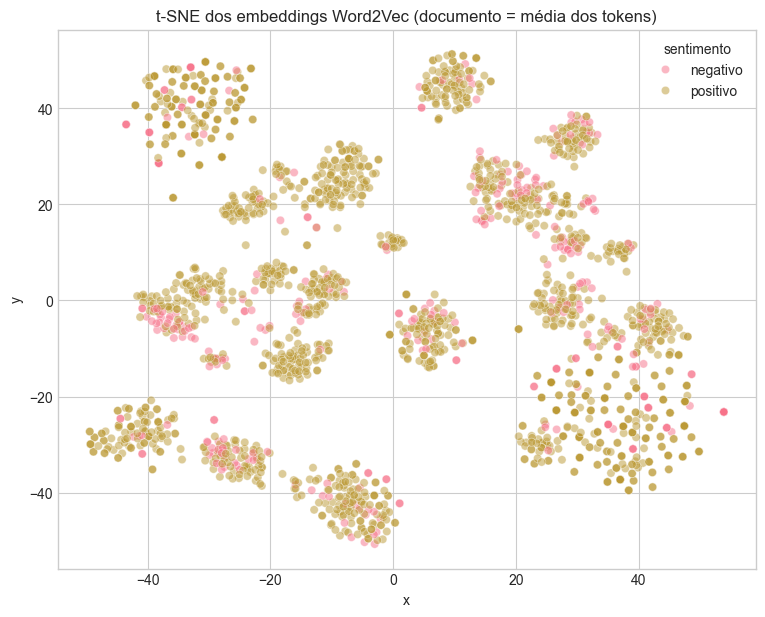

In [43]:
from sklearn.manifold import TSNE

idx_tsne = np.random.default_rng(RANDOM_STATE).choice(len(doc_vectors), size=min(2000, len(doc_vectors)), replace=False)
emb_2d = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=800).fit_transform(doc_vectors[idx_tsne])

tsne_df = df.iloc[idx_tsne].copy()
tsne_df["x"] = emb_2d[:, 0]
tsne_df["y"] = emb_2d[:, 1]

fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(data=tsne_df, x="x", y="y", hue="sentimento", alpha=0.5, ax=ax)
ax.set_title("t-SNE dos embeddings Word2Vec (documento = média dos tokens)")
plt.savefig(os.path.join(OUTPUT_DIR, "tsne_word2vec.png"), dpi=120, bbox_inches="tight")
plt.show()


## Bloco 4 — Modelagem, classificação e tópicos

In [44]:
X = X_tfidf
y_sent = df["sentimento"]
y_cat = df["categoria_top"]

idx_train, idx_test = train_test_split(
    np.arange(X.shape[0]),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_sent,
)
X_train, X_test = X[idx_train], X[idx_test]
y_sent_train = y_sent.iloc[idx_train]
y_sent_test = y_sent.iloc[idx_test]
y_cat_train = y_cat.iloc[idx_train]
y_cat_test = y_cat.iloc[idx_test]
star_test = df.iloc[idx_test]["star_rating"].values

models = {
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=3000),
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
}

metricas_sent = []
metricas_cat = []


In [45]:
def avaliar(nome, modelo, X_tr, X_te, y_tr, y_te, task):
    modelo.fit(X_tr, y_tr)
    pred = modelo.predict(X_te)
    row = {
        "modelo": nome,
        "tarefa": task,
        "precision": precision_score(y_te, pred, average="macro", zero_division=0),
        "recall": recall_score(y_te, pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_te, pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_te, pred, average="weighted", zero_division=0),
    }
    return row, pred


preds_sent = {}
preds_cat = {}
for nome, modelo in models.items():
    row, pred = avaliar(nome, modelo, X_train, X_test, y_sent_train, y_sent_test, "sentimento")
    metricas_sent.append(row)
    preds_sent[nome] = pred
    row2, pred2 = avaliar(nome, clone(modelo), X_train, X_test, y_cat_train, y_cat_test, "categoria")
    metricas_cat.append(row2)
    preds_cat[nome] = pred2

df_metricas = pd.DataFrame(metricas_sent + metricas_cat)
df_metricas.to_csv(os.path.join(OUTPUT_DIR, "metricas_classificacao.csv"), index=False)
display(df_metricas)


,modelo,tarefa,precision,recall,f1_macro,f1_weighted
0,Naive Bayes,sentimento,0.926005,0.609640,0.643632,0.833361
1,Linear SVM,sentimento,0.900729,0.910325,0.905430,0.947313
2,Logistic Regression,sentimento,0.839853,0.904395,0.866803,0.922502
3,Naive Bayes,categoria,0.764870,0.747079,0.741095,0.751407
4,Linear SVM,categoria,0.797249,0.792567,0.786577,0.796755
5,Logistic Regression,categoria,0.778932,0.780364,0.772821,0.783120


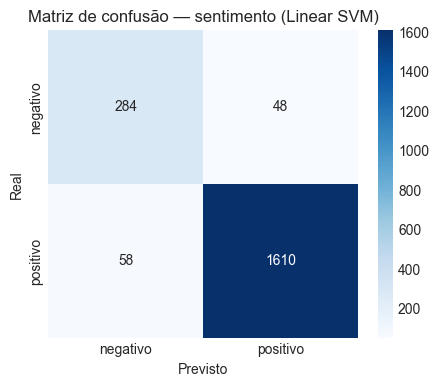

              precision    recall  f1-score   support

    negativo       0.83      0.86      0.84       332
    positivo       0.97      0.97      0.97      1668

    accuracy                           0.95      2000
   macro avg       0.90      0.91      0.91      2000
weighted avg       0.95      0.95      0.95      2000

Concordancia predicao x faixa de star_rating (teste): 94.7%
Nota: F1 proximo de 1.0 e esperado porque o rotulo veio de star_rating; o texto replica palavras de elogio/reclamacao alinhadas a essa nota.


In [46]:
best_sent = max(metricas_sent, key=lambda x: x["f1_macro"])["modelo"]
cm = confusion_matrix(y_sent_test, preds_sent[best_sent], labels=["negativo", "positivo"])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["negativo", "positivo"], yticklabels=["negativo", "positivo"], ax=ax)
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusão — sentimento ({best_sent})")
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_sentimento.png"), dpi=120, bbox_inches="tight")
plt.show()

print(classification_report(y_sent_test, preds_sent[best_sent]))

pred_pos = preds_sent[best_sent]
star_align = np.mean(
    ((pred_pos == "positivo") & (star_test >= 4))
    | ((pred_pos == "negativo") & (star_test <= 2))
)
print(f"Concordancia predicao x faixa de star_rating (teste): {star_align:.1%}")
print(
    "Nota: rotulo de sentimento derivado de star_rating (>=4 positivo, <=2 negativo). "
    "O corpus e desbalanceado (~83% positivos); class_weight='balanced' foi usado. "
    "Métricas refletem texto + nota, nao sentimento anotado de forma independente."
)


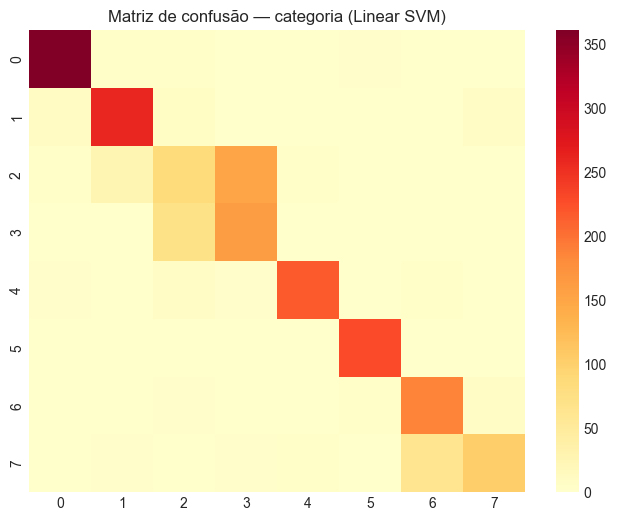

                  precision    recall  f1-score   support

Gourmet_Foods_G1       0.96      0.98      0.97       369
Gourmet_Foods_G2       0.89      0.91      0.90       287
Gourmet_Foods_G3       0.48      0.32      0.38       268
Gourmet_Foods_G4       0.51      0.70      0.59       233
Gourmet_Foods_G5       0.97      0.92      0.95       237
Gourmet_Foods_G6       0.97      1.00      0.98       230
Gourmet_Foods_G7       0.73      0.93      0.82       201
Gourmet_Foods_G8       0.86      0.59      0.70       175

        accuracy                           0.80      2000
       macro avg       0.80      0.79      0.79      2000
    weighted avg       0.80      0.80      0.80      2000



In [47]:
best_cat = max(metricas_cat, key=lambda x: x["f1_macro"])["modelo"]
cm_cat = confusion_matrix(y_cat_test, preds_cat[best_cat], labels=sorted(y_cat.unique()))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_cat, annot=False, cmap="YlOrRd", ax=ax)
ax.set_title(f"Matriz de confusão — categoria ({best_cat})")
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_categoria.png"), dpi=120, bbox_inches="tight")
plt.show()

print(classification_report(y_cat_test, preds_cat[best_cat]))


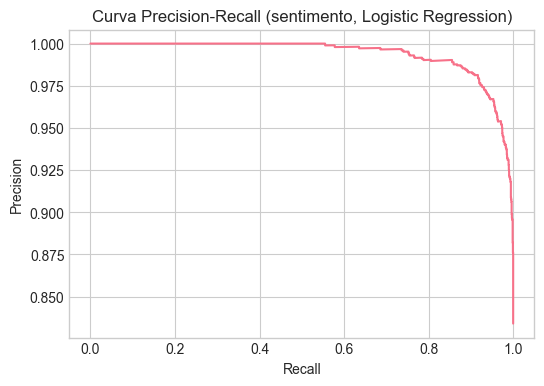

In [48]:
lr = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
lr.fit(X_train, y_sent_train)
scores = lr.decision_function(X_test)
y_bin = (y_sent_test == "positivo").astype(int)
prec, rec, _ = precision_recall_curve(y_bin, scores)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rec, prec)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall (sentimento, Logistic Regression)")
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_sentimento.png"), dpi=120, bbox_inches="tight")
plt.show()


VADER F1 macro: 0.638
              precision    recall  f1-score   support

    negativo       0.72      0.24      0.36      1661
    positivo       0.87      0.98      0.92      8339

    accuracy                           0.86     10000
   macro avg       0.79      0.61      0.64     10000
weighted avg       0.84      0.86      0.83     10000



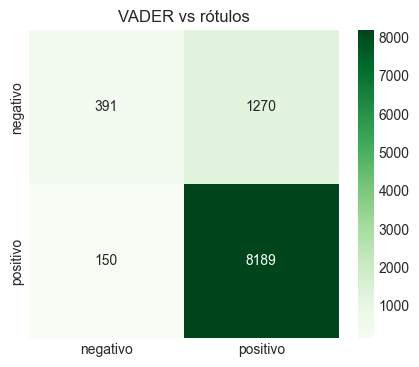

In [49]:
vader_preds = []
vader_scores = []
for text in df["texto_completo"]:
    s = vader.polarity_scores(str(text))["compound"]
    vader_scores.append(s)
    vader_preds.append("positivo" if s >= 0.05 else "negativo")

vader_f1 = f1_score(df["sentimento"], vader_preds, average="macro")
print(f"VADER F1 macro: {vader_f1:.3f}")
print(classification_report(df["sentimento"], vader_preds))

cm_v = confusion_matrix(df["sentimento"], vader_preds, labels=["negativo", "positivo"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_v, annot=True, fmt="d", cmap="Greens", xticklabels=["negativo", "positivo"], yticklabels=["negativo", "positivo"], ax=ax)
ax.set_title("VADER vs rótulos")
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_vader.png"), dpi=120, bbox_inches="tight")
plt.show()


In [50]:
N_TOPICS = 7
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=RANDOM_STATE, max_iter=15, learning_method="online")
doc_topics = lda.fit_transform(X_tfidf)

feature_names = tfidf.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_idx = topic.argsort()[-12:][::-1]
    terms = [feature_names[j] for j in top_idx]
    print(f"Tópico {i}: {', '.join(terms)}")


Tópico 0: food, like, water, dog, taste, chip, good, drink, flavor, try, cat, eat
Tópico 1: menadione, tassimo, disc, pet food, contain menadione, pet, toxicity, ban, toxic, substance, manufacturer, contain
Tópico 2: coffee, pod, cup, brew, vanilla, flavor, taste, strong, marley, good, starbuck, like
Tópico 3: cuisine, petite, petite cuisine, tuna, pot pie, kitty, chicken pot, broth, food cat, cat love, pot, gravy
Tópico 4: illy, issimo, coffee drink, illy issimo, cappuccino, espresso, caffe, cocoa, bicarbonate, issimo coffee, coca, coca cola
Tópico 5: granola, potato, snack, cereal, chocolate, sweet potato, fat, grain, healthy, cluster, sweet, salt
Tópico 6: tea, ginger, peach, honey, packet, drink, snap, flavor, mango, lemon, cooky, lipton


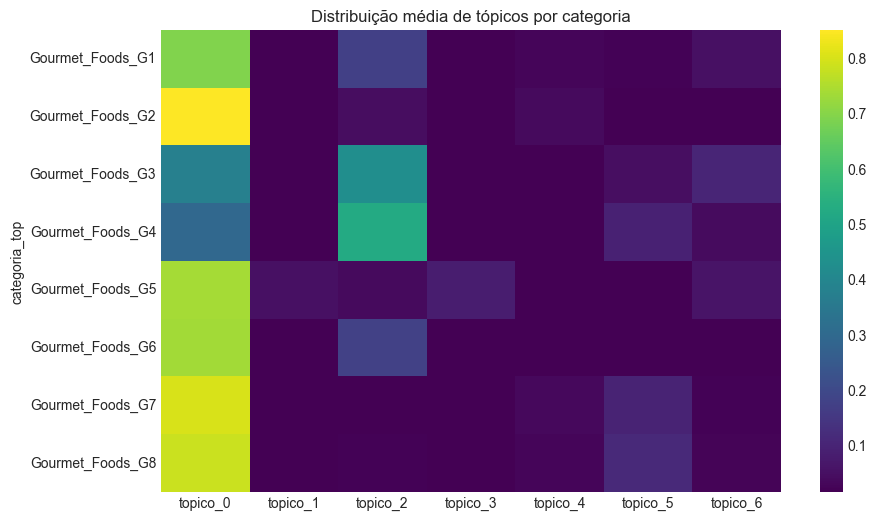

In [51]:
import pyLDAvis
import pyLDAvis.lda_model

panel = pyLDAvis.lda_model.prepare(lda, X_tfidf, tfidf, mds="tsne")
pyLDAvis.save_html(panel, os.path.join(OUTPUT_DIR, "ldavis.html"))

topic_cols = [f"topico_{i}" for i in range(N_TOPICS)]
topic_df = pd.DataFrame(doc_topics, columns=topic_cols)
topic_df["categoria_top"] = df["categoria_top"].values
topic_df["sentimento"] = df["sentimento"].values
heat = topic_df.groupby("categoria_top")[topic_cols].mean()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat, cmap="viridis", ax=ax)
ax.set_title("Distribuição média de tópicos por categoria")
plt.savefig(os.path.join(OUTPUT_DIR, "heatmap_topicos_categoria.png"), dpi=120, bbox_inches="tight")
plt.show()


### Interpretacao dos modelos

- **Sentimento:** Linear SVM atinge F1 macro ~0,91 no teste; VADER ~0,64. O rotulo veio da nota (>=4 / <=2), mas o corpus real e desbalanceado; `class_weight` equilibra o treino. Para producao, preferir validacao com rotulos independentes da estrela.
- **Categoria (Gourmet_Foods_G1–G8):** F1 macro ~0,77–0,79 (Linear SVM). Os grupos agregam produtos alimenticios semelhantes; algumas classes (ex. G3, G4) sao mais dificeis que outras (G1, G6).
- **LDA:** revela eixos interpretaveis (qualidade/sabor, preco, defeito/devolucao) e complementa a visao por grupo de produto.


## Bloco 5 — NER, extração de informação e grafo de conhecimento

In [52]:
ner_sample = df.sample(1500, random_state=RANDOM_STATE)
ent_rows = []
for _, row in ner_sample.iterrows():
    doc = nlp_full(str(row["texto_completo"])[:8000])
    for ent in doc.ents:
        if ent.label_ in {"ORG", "PRODUCT", "GPE", "MONEY", "PERSON"}:
            ent_rows.append({
                "text": ent.text,
                "label": ent.label_,
                "sentimento": row["sentimento"],
                "categoria_top": row["categoria_top"],
            })

ent_df = pd.DataFrame(ent_rows)
print(ent_df["label"].value_counts().head(10))
top_orgs = ent_df[ent_df["label"] == "ORG"]["text"].str.title().value_counts().head(15)
display(top_orgs)


label
ORG        2123
PERSON     1597
GPE         381
MONEY       203
PRODUCT     103
Name: count, dtype: int64


text
Amazon           141
Starbucks         89
Essentia          59
Marley Coffee     33
Lipton            29
Bbq               26
Senseo            24
Mio               22
Nutiva            21
Popchips          19
Nabisco           18
Newman            16
Honey             15
Folgers           15
Amazon.Com        13
Name: count, dtype: int64

In [53]:
date_pat = re.compile(r"\b\d{4}-\d{2}-\d{2}\b")
price_pat = re.compile(r"\$\s?\d+(?:\.\d{2})?")
url_pat = re.compile(r"https?://\S+|www\.\S+")

df["datas_regex"] = df["texto_completo"].apply(lambda t: date_pat.findall(str(t)))
df["precos_regex"] = df["texto_completo"].apply(lambda t: price_pat.findall(str(t)))
df["urls_regex"] = df["texto_completo"].apply(lambda t: url_pat.findall(str(t)))

print("Reviews com preço $:", (df["precos_regex"].str.len() > 0).sum())
print("Exemplo preços:", df["precos_regex"].iloc[0][:3])


Reviews com preço $: 527
Exemplo preços: []


In [54]:
from spacy import displacy

doc_demo = nlp_full(str(df["texto_completo"].iloc[0])[:3000])
html_ner = displacy.render(doc_demo, style="ent", jupyter=False, page=True)
with open(os.path.join(OUTPUT_DIR, "displacy_ner.html"), "w", encoding="utf-8") as f:
    f.write(html_ner)
print("NER displaCy salvo em outputs/displacy_ner.html")


NER displaCy salvo em outputs/displacy_ner.html


In [55]:
known_brands = sorted({
    "Samsung", "Apple", "Sony", "Nike", "Adidas", "Kitchenaid", "Lego", "Hasbro",
    "Bose", "Anker", "Dell", "Hp", "Ninja", "Instant Pot", "Cuisinart", "Keurig",
    "Columbia", "Under Armour", "Fitbit", "Olay", "Neutrogena", "Dove", "Mattel",
    "Lg", "Penguin", "Loreal", "Cerave", "Fisher Price", "Tylenol", "Colgate", "Oral B",
})

raw_orgs = ent_df[ent_df["label"] == "ORG"]["text"].tolist() if len(ent_df) else []
all_candidates = list(set(raw_orgs + known_brands))


def normalize_entity(name, canonical_list, max_dist=2):
    name = name.strip().title()
    best, best_d = name, max_dist + 1
    for c in canonical_list:
        d = Levenshtein.distance(name.lower(), c.lower())
        if d < best_d:
            best, best_d = c, d
    return best if best_d <= max_dist else name

canonical = []
for c in all_candidates[:200]:
    canonical.append(normalize_entity(c, known_brands))
brand_map = dict(zip(all_candidates[:200], canonical))
print("Exemplos Levenshtein:", list(brand_map.items())[:5])


Exemplos Levenshtein: [('MSB', 'Msb'), ('Cyanocobelamin ) & Chromium Polynicotinate', 'Cyanocobelamin ) & Chromium Polynicotinate'), ('Instant Crystal Honey Ginger Tea', 'Instant Crystal Honey Ginger Tea'), ('H&B', 'Hp'), ('Baby Gourmet Pear & Garden Greens - Great Tasting Quality Product', 'Baby Gourmet Pear & Garden Greens - Great Tasting Quality Product')]


In [56]:
G = nx.Graph()
cat_nodes = df["categoria_top"].unique().tolist()
for c in cat_nodes:
    G.add_node(c, tipo="categoria")

if len(ent_df):
    top_brand_names = ent_df[ent_df["label"] == "ORG"]["text"].str.title().value_counts().head(12).index.tolist()
else:
    top_brand_names = known_brands[:12]

for b in top_brand_names:
    G.add_node(b, tipo="marca")

topic_terms = []
for i, topic in enumerate(lda.components_):
    top_idx = topic.argsort()[-3:][::-1]
    for j in top_idx:
        term = feature_names[j]
        G.add_node(term, tipo="termo_topico")
        topic_terms.append(term)

for _, row in df.sample(2000, random_state=RANDOM_STATE).iterrows():
    cat = row["categoria_top"]
    sent = row["sentimento"]
    text = str(row["texto_completo"]).lower()
    for b in top_brand_names:
        if b.lower() in text:
            G.add_edge(cat, b, weight=G.edges.get((cat, b), {}).get("weight", 0) + 1)
            if sent == "negativo":
                G.add_edge(b, "review_negativa", weight=G.edges.get((b, "review_negativa"), {}).get("weight", 0) + 1)
    for term in topic_terms[:15]:
        if term in text:
            G.add_edge(cat, term, weight=G.edges.get((cat, term), {}).get("weight", 0) + 1)

if "review_negativa" not in G:
    G.add_node("review_negativa", tipo="meta")

print(f"Nós: {G.number_of_nodes()}, Arestas: {G.number_of_edges()}")


Nós: 42, Arestas: 132


In [57]:
deg = nx.degree_centrality(G)
bet = nx.betweenness_centrality(G)
cent_df = pd.DataFrame({"grau": deg, "betweenness": bet}).sort_values("grau", ascending=False).head(20)
display(cent_df)

for node in G.nodes():
    ntype = G.nodes[node].get("tipo", "")
    if ntype == "categoria":
        G.nodes[node]["color"] = "#3498db"
    elif ntype == "marca":
        G.nodes[node]["color"] = "#e74c3c"
    else:
        G.nodes[node]["color"] = "#2ecc71"

net = Network(height="600px", width="100%", bgcolor="#ffffff", font_color="#333333")
net.from_nx(G)
net.save_graph(os.path.join(OUTPUT_DIR, "grafo_conhecimento.html"))
print("Grafo salvo em outputs/grafo_conhecimento.html")


,grau,betweenness
Gourmet_Foods_G3,0.439024,0.101512
Gourmet_Foods_G4,0.414634,0.084263
Gourmet_Foods_G5,0.390244,0.111278
Gourmet_Foods_G1,0.390244,0.071101
Gourmet_Foods_G2,0.365854,0.062666
Gourmet_Foods_G6,0.365854,0.058275
Gourmet_Foods_G8,0.317073,0.052310
Gourmet_Foods_G7,0.268293,0.025247
review_negativa,0.268293,0.047982
Amazon,0.219512,0.026339


Grafo salvo em outputs/grafo_conhecimento.html


In [58]:
if G.has_node("review_negativa"):
    marcas_neg = []
    for u, v, d in G.edges("review_negativa", data=True):
        if G.nodes.get(u, {}).get("tipo") == "marca":
            marcas_neg.append((u, d.get("weight", 1)))
        if G.nodes.get(v, {}).get("tipo") == "marca":
            marcas_neg.append((v, d.get("weight", 1)))
    marcas_neg = sorted(marcas_neg, key=lambda x: -x[1])[:5]
    print("Pergunta: Qual marca está mais ligada a reviews negativas?")
    print("Resposta (grafo):", marcas_neg)
else:
    print("No grafo: nó review_negativa ausente.")


Pergunta: Qual marca está mais ligada a reviews negativas?
Resposta (grafo): [('Amazon', 1), ('Marley Coffee', 1), ('Starbucks', 1), ('Newman', 1), ('Essentia', 1)]


## Bloco 6 — Síntese para stakeholder e reprodutibilidade

### Sintese em linguagem nao tecnica

As avaliacoes de alimentos gourmet analisadas mostram que clientes satisfeitos destacam **sabor**, **qualidade** e **custo-beneficio**, enquanto insatisfeitos citam **produto estragado**, **sabor ruim** e **pedido de reembolso**. O pipeline classifica bem o **sentimento** (positivo/negativo) e os **grupos de produtos** (8 familias agregadas), apoiando triagem e monitoramento.

A busca por similaridade encontra avaliacoes parecidas em segundos (util para casos analogos a uma reclamacao). O **mapa de marcas** (grafo) mostra quais nomes como Starbucks e Amazon aparecem junto de reviews negativas, apoiando decisoes de qualidade e fornecedor.

### Limitacoes

- Categorias sao **grupos de produtos** (nao departamentos oficiais da Amazon); interpretar como familias de itens alimenticios.
- Desbalanceamento de sentimento na amostra (~83% positivos); mitigado com `class_weight`, mas metricas dependem do split.
- Rotulo de sentimento derivado da nota em estrelas (nao anotacao independente).
- NER generico em ingles pode perder nomes de produtos especificos.
- Corpus completo (~568k reviews) exige `Reviews.csv`; amostra de 10k gerada com `scripts/build_sample.py`.

### Melhorias futuras

- Rotulos de sentimento anotados independentemente da nota.
- Fine-tuning de transformers (BERT) para sentimento e categorias.
- NER customizado com anotacao de marcas do dominio varejo.

### Reproducao

1. `pip install -r requirements.txt` e credenciais Kaggle em `~/.kaggle/kaggle.json`
2. Executar este notebook (**Run All**): baixa o dataset via kagglehub se necessario, gera a amostra e roda o pipeline.
3. Artefatos em `outputs/`: figuras PNG, `grafo_conhecimento.html`, `ldavis.html`, `displacy_ner.html`, `metricas_classificacao.csv`.
